In [2]:
import pandas as pd
import seaborn as sns

In [3]:
pip install --upgrade certifi

Note: you may need to restart the kernel to use updated packages.


In [4]:
tips = sns.load_dataset('tips')

In [5]:
titanic = pd.read_csv('Titanic-Dataset.csv')

In [6]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

flights = sns.load_dataset('flights')

In [7]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [8]:
iris = sns.load_dataset('iris')

In [9]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Scatterplot(Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

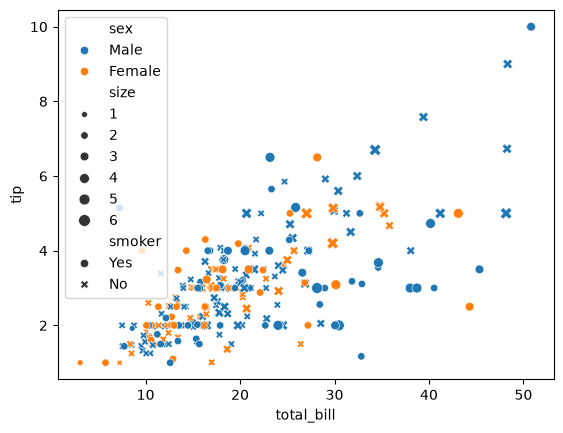

In [10]:
sns.scatterplot(data=tips, x='total_bill', y='tip',hue=tips['sex'],style=tips['smoker'],size=tips['size'])

## 2. Bar plot (Numerical - Categorical)

In [11]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Age'>

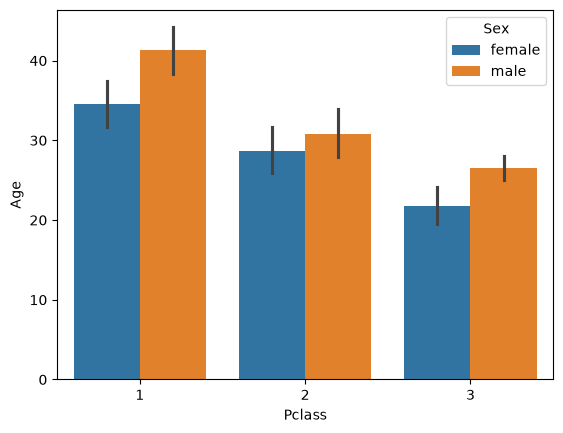

In [12]:
sns.barplot(data=titanic,x='Pclass',y='Age',hue=titanic['Sex'])

<Axes: xlabel='Pclass', ylabel='Fare'>

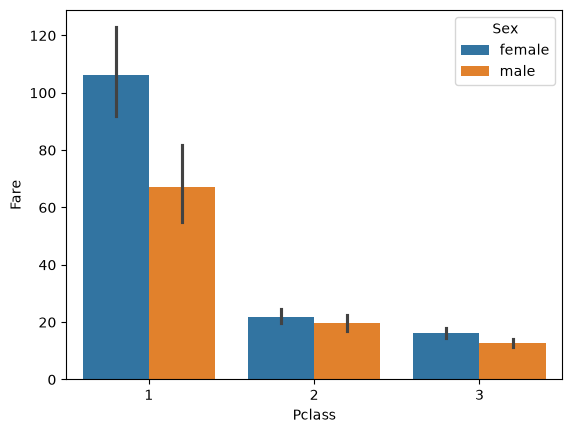

In [13]:
sns.barplot(data=titanic,x='Pclass',y='Fare',hue=titanic['Sex'])

## 3. Box Plot(Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

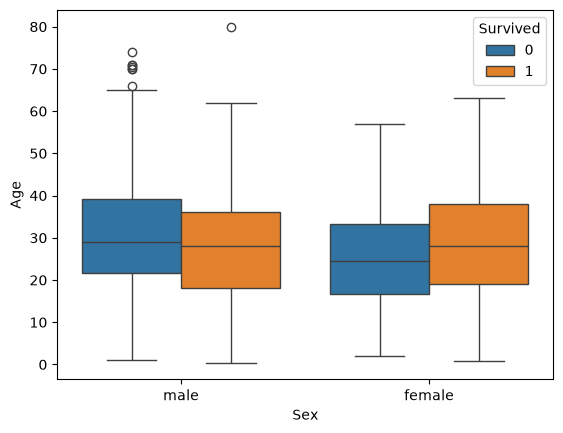

In [16]:
sns.boxplot(data=titanic,x='Sex',y = 'Age',hue=titanic['Survived'])

## 4. Histplot(Numerical - Categorical) 

<Axes: xlabel='Age', ylabel='Count'>

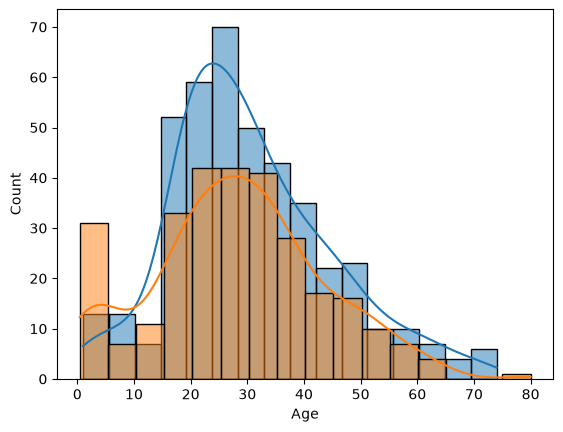

In [21]:
sns.histplot(titanic[titanic['Survived'] == 0]['Age'],kde=True)
sns.histplot(titanic[titanic['Survived'] == 1]['Age'],kde=True)

## 5. HeatMap(Categorical - Categorical)

<Axes: xlabel='Survived', ylabel='Pclass'>

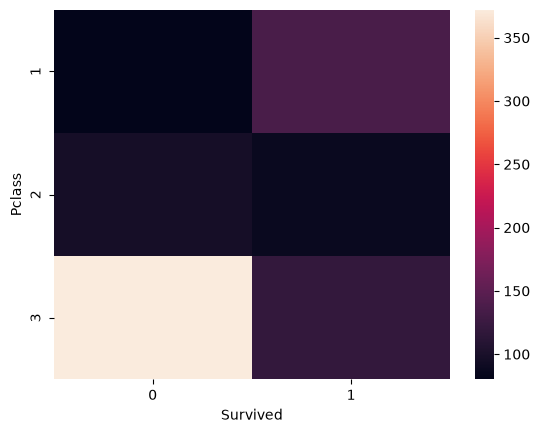

In [23]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

In [28]:
titanic.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [29]:
titanic.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [30]:
titanic.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

## 6. ClusterMap(Categorical - Categorical)

In [36]:
pd.crosstab(titanic['Parch'],titanic['Survived'])

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


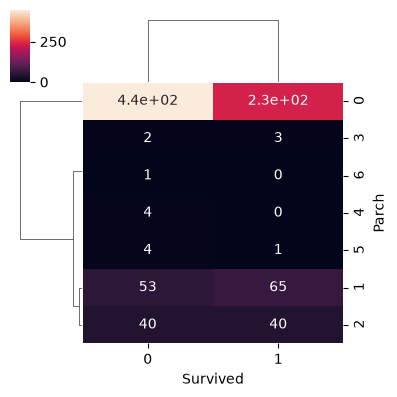

In [37]:
sns.clustermap(pd.crosstab(titanic['Parch'],titanic['Survived']),figsize=(4,4),annot = True)

## 7. Pairplot

In [34]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


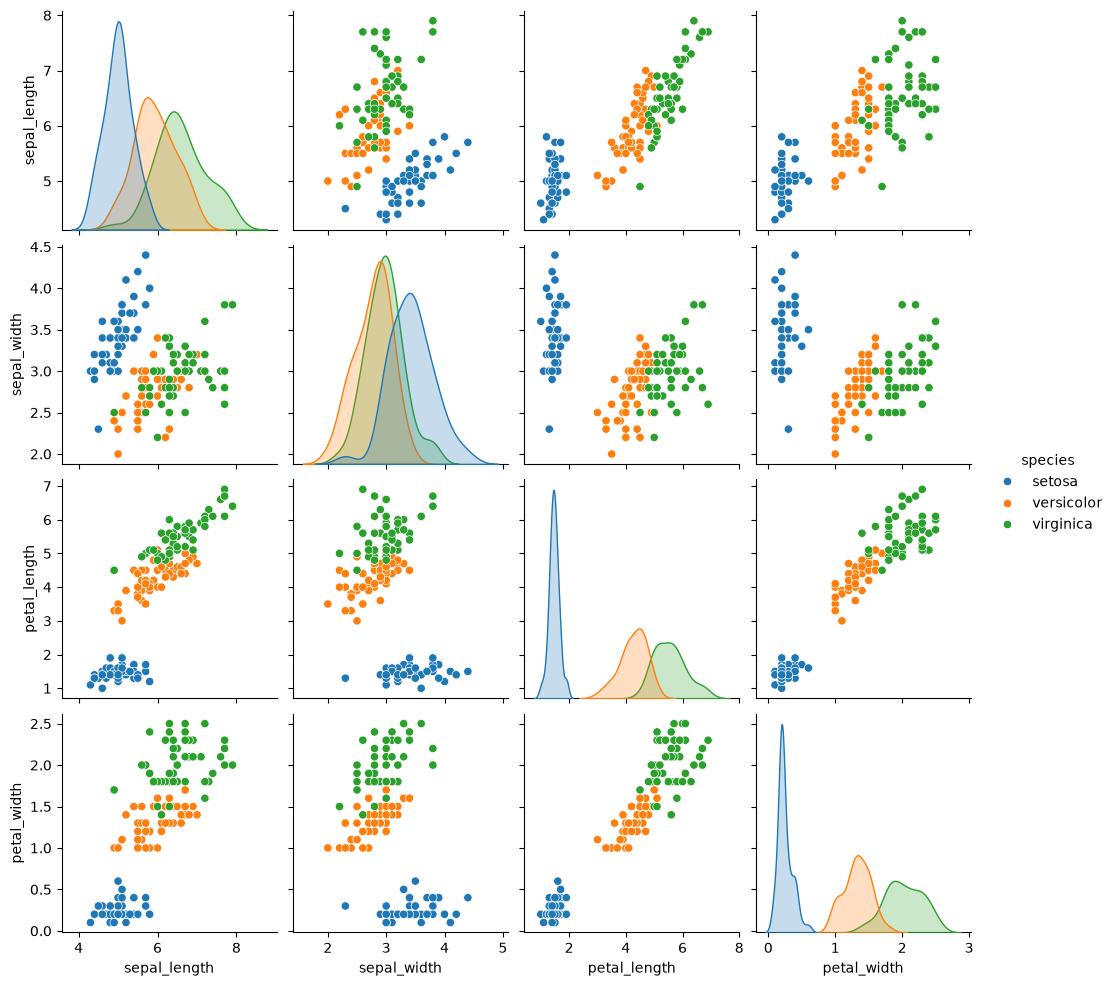

In [38]:
sns.pairplot(iris,hue='species')

## Lineplot (Numerical - Numerical)

In [39]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [42]:
new = flights.groupby('year').sum(numeric_only=True)

<Axes: xlabel='year', ylabel='passengers'>

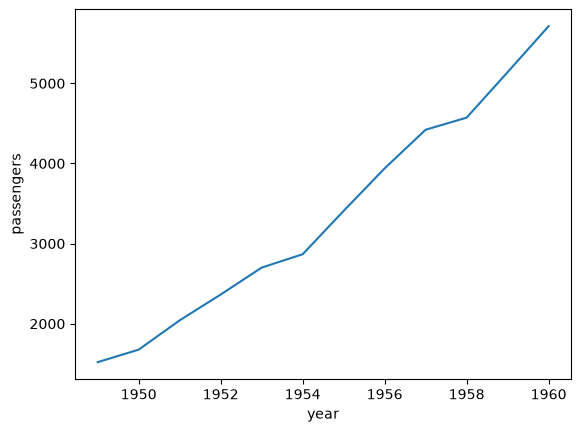

In [44]:
sns.lineplot(x='year', y='passengers', data=new)

<Axes: xlabel='year', ylabel='month'>

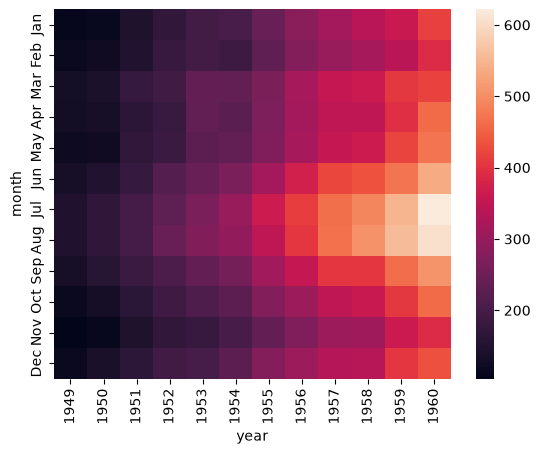

In [46]:
sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))

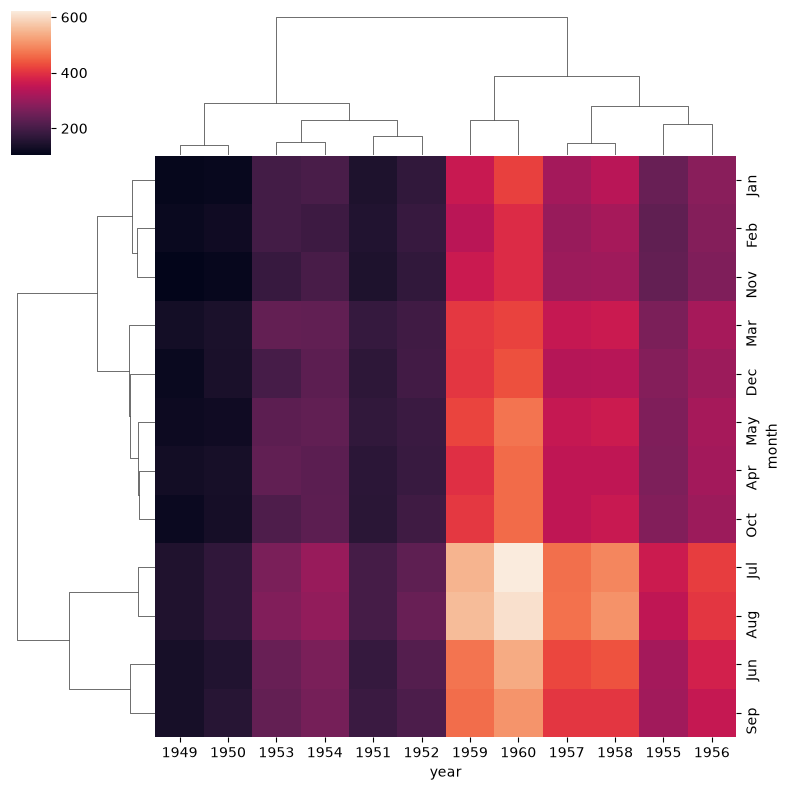

In [50]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'),figsize=(8,8))